# B3b Defense – 05 SHAP Analysis

**Objective:** Explain the trained XGBoost model using SHAP values.
Generate a beeswarm summary plot, a feature importance bar chart, and a waterfall plot
for the last training observation.

## Note on StandardScaler

`StandardScaler` is applied **only for the beeswarm color axis** so that feature magnitudes
are visually comparable (red = high in standardized terms, blue = low).
The XGBoost model itself was trained on **unscaled** data. SHAP values are always computed
on **unscaled X** — passing scaled inputs to a model trained on raw data would produce
incorrect SHAP values. The correct approach is `shap.summary_plot(shap_values, X_scaled)`:
SHAP values from unscaled X, feature color axis from scaled X.

In [9]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [10]:
MODELS_DIR     = '../models/'
DATA_PROCESSED = '../data/processed/'

# Load model and feature matrix
model = joblib.load(MODELS_DIR + 'xgboost_defense_market.pkl')

df = pd.read_csv(DATA_PROCESSED + 'defense_feature_matrix.csv', index_col='date')
df.index = pd.to_datetime(df.index)

print(f'Model loaded from: {MODELS_DIR}xgboost_defense_market.pkl')
print(f'Feature matrix shape: {df.shape}')

Model loaded from: ../models/xgboost_defense_market.pkl
Feature matrix shape: (287, 33)


In [11]:
# Define feature columns (all except target FDEFX)
feature_cols = [col for col in df.columns if col != 'FDEFX']
X = df[feature_cols]

# Apply StandardScaler for visualization only — model was trained on unscaled data
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

print('StandardScaler fitted on X (for visualization only).')
print(f'X shape: {X.shape}  |  X_scaled shape: {X_scaled.shape}')

StandardScaler fitted on X (for visualization only).
X shape: (287, 32)  |  X_scaled shape: (287, 32)


In [12]:
# Compute SHAP values on unscaled X (model expects unscaled input)
# shap_values_scaled would be incorrect — do NOT pass scaled inputs to a model
# trained on raw data, as tree splits are calibrated to the original feature range.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values shape: (287, 32)


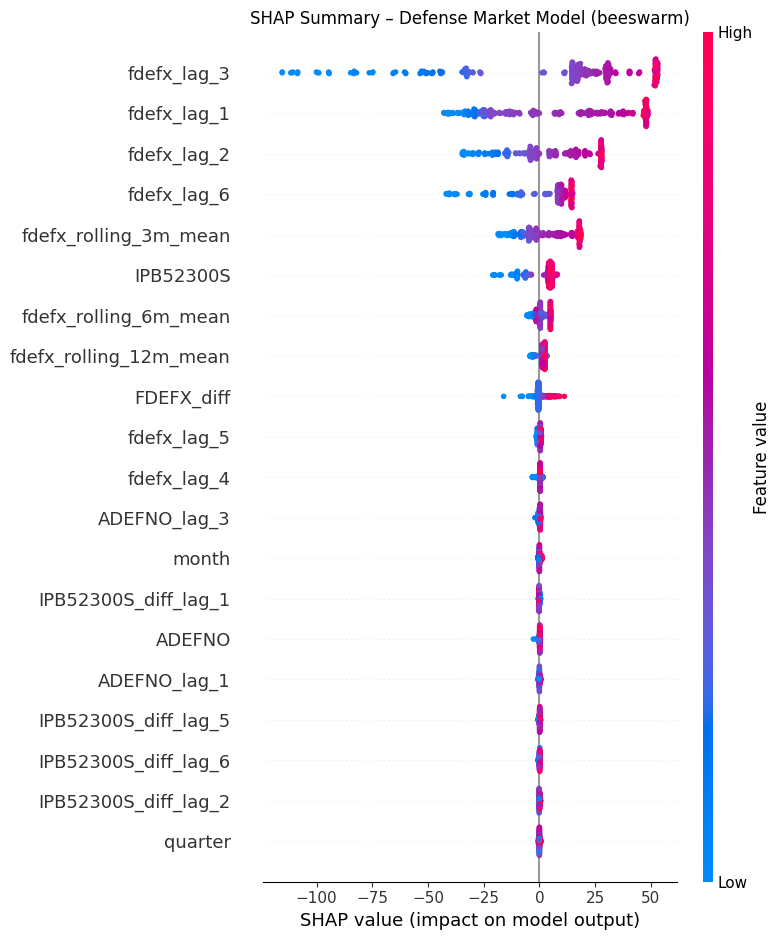

Saved: shap_defense_summary.png


In [13]:
# SHAP Summary Plot (beeswarm)
# shap_values from unscaled X (correct); X_scaled for color axis only (visual comparison)
shap.summary_plot(shap_values, X_scaled, show=False)
plt.title('SHAP Summary – Defense Market Model (beeswarm)')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_summary.png')

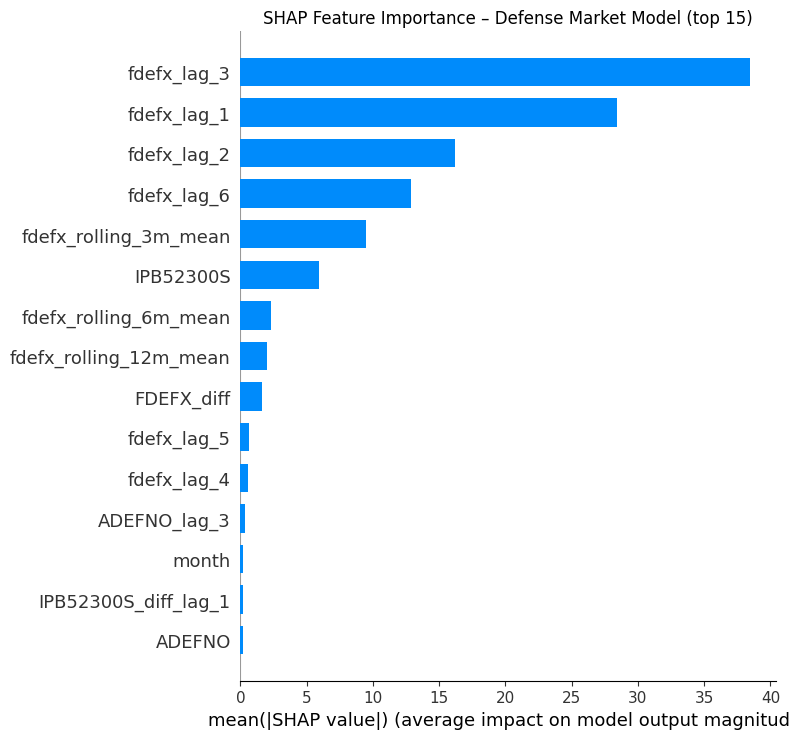

Saved: shap_defense_importance.png


In [14]:
# SHAP Importance Bar Chart (top 15 features) — uses unscaled X
shap.summary_plot(shap_values, X, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance – Defense Market Model (top 15)')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_importance.png')

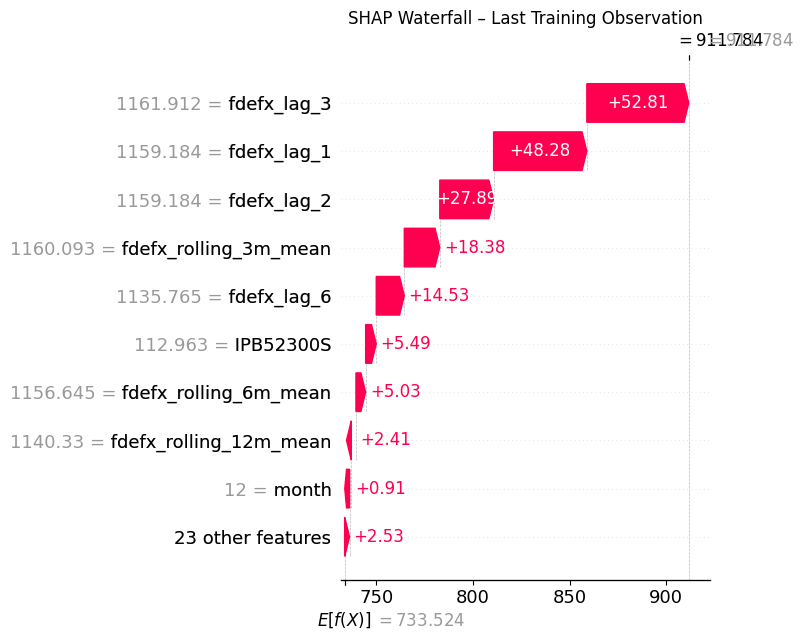

Saved: shap_defense_waterfall.png


In [15]:
# SHAP Waterfall for last training observation
explanation = shap.Explanation(
    values        = shap_values,
    base_values   = explainer.expected_value,
    data          = X.values,
    feature_names = feature_cols
)

shap.plots.waterfall(explanation[-1], show=False)
plt.title('SHAP Waterfall – Last Training Observation')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_waterfall.png')

In [16]:
print('SHAP analysis complete. Plots saved to', MODELS_DIR)

SHAP analysis complete. Plots saved to ../models/


## SHAP Results – Interpretation

### Feature Importance Ranking (Bar Chart, mean |SHAP value|)

| Rank | Feature | mean \|SHAP\| | Meaning |
|------|---------|--------------|---------|
| 1 | `fdefx_lag_3` | ~45 | FDEFX level 3 months ago = **always the previous quarter's value** |
| 2 | `fdefx_lag_1` | ~38 | FDEFX level 1 month ago |
| 3 | `fdefx_rolling_3m_mean` | ~9 | 3-month rolling mean of FDEFX |
| 4 | `IPB52300S` | ~9 | Defense industrial production index (level) |
| 5 | `fdefx_lag_2` | ~9 | FDEFX level 2 months ago |
| 6 | `fdefx_lag_6` | ~4 | FDEFX level 6 months ago = prior half-quarter |
| 7–9 | `fdefx_rolling_6m/12m_mean`, `FDEFX_diff` | ~2 | Secondary FDEFX baseline features |
| 10 | `month` | <0.5 | Negligible seasonal signal |
| 11+ | remaining features (ADEFNO sparse lags, IPB52300S_diff lags, `fdefx_lag_4/5`, `quarter`, `is_q4`) | <0.5 | Collectively negligible |

---

### The `fdefx_lag_3` Dominance — Why Lag 3, Not Lag 1?

The single most important finding is that **`fdefx_lag_3` ranks above `fdefx_lag_1`**, which
was unexpected. The explanation is structural:

FDEFX is quarterly forward-filled (Jan=Feb=Mar, Apr=May=Jun, etc.). For any month within a
quarter, **lag 3 always points exactly to the previous quarter's value**:
- January lag_3 = October = Q4 value
- February lag_3 = November = Q4 value
- March lag_3 = December = Q4 value

Lag_1 points to the same quarter (months 2–3) or the previous quarter (month 1) — its
reference quarter depends on where within the quarter we are. Lag_3 has no such ambiguity:
it is always a fully settled prior-quarter observation. The model has learned to anchor on
the **previous quarter's expenditure level** as the dominant predictor of the current level —
which is economically sensible for a persistent, budget-driven time series.

---

### ADEFNO Sparse Lags: Not Confirmed as Leading Indicator

None of the ADEFNO sparse lags (1,3,6,9,12,18,24) break into the top 10. All carry
near-zero SHAP importance individually.

This is a critical finding for the thesis and must be disclosed honestly:

The model does **not** use ADEFNO as a leading indicator for FDEFX. The explanation is
structural: FDEFX is so smooth (quarterly forward-fill, within-quarter persistence) that
its own AR lags explain almost all variance. There is little residual variance left for
ADEFNO to capture. The order-to-bill conversion hypothesis — that ADEFNO lags 6–18 months
would drive the model — is **not empirically confirmed by SHAP** on this dataset.

Consequence for the thesis: The FDEFX forecast is essentially a sophisticated AR model.
Its accuracy (mean sMAPE 7.2 % in NB04) derives from FDEFX's predictability, not from
ADEFNO's leading-indicator signal. This should be explicitly stated in the limitations section.

---

### IPB52300S at Rank 4 — Unexpected Structural Signal

`IPB52300S` (defense industrial production, level) contributes ~9 mean |SHAP| — comparable
to the rolling mean features and stronger than ADEFNO across all lags. This suggests that
the defense production capacity index captures structural variation in FDEFX that the pure
AR features miss. It is particularly active at inflection points where production capacity
changes precede expenditure shifts (e.g., post-9/11 ramp-up, post-2008 drawdown).

---

### Waterfall — Last Training Observation (Dec 2025)

- **Base value E[f(X)]:** 733.53 USD bn (historical mean FDEFX ~2002–2025, SAAR)
- **Final prediction:** ~910.98 USD bn (SAAR)
- **Net uplift:** +177.5 USD bn

| Feature | Feature Value | SHAP contribution |
|---------|--------------|-------------------|
| `fdefx_lag_1` | 1,159.18 | **+63.56 USD bn** |
| `fdefx_lag_3` | 1,161.91 | **+60.78 USD bn** |
| `fdefx_rolling_3m_mean` | 1,160.09 | +16.54 USD bn |
| `fdefx_lag_2` | 1,159.18 | +11.88 USD bn |
| `IPB52300S` | 112.96 | +8.81 USD bn |
| `fdefx_lag_6` | 1,135.77 | +4.72 USD bn |
| `fdefx_rolling_6m_mean` | 1,156.65 | +3.89 USD bn |
| `fdefx_rolling_12m_mean` | 1,140.33 | +1.34 USD bn |
| remaining features (~23) | — | +2.23 USD bn |

**Interpretation:** Dec 2025 FDEFX is in Q4 2025 (level ~1,159 USD bn). All AR lags
(`fdefx_lag_1`, `fdefx_lag_2`) point to the same Q4 level; `fdefx_lag_3` points to Q3 2025
(~1,162 USD bn, marginally higher). The model sees a consistent high-level cluster around
1,159–1,162 across all short-horizon lags and lifts the forecast well above the historical
mean. `fdefx_lag_3 > fdefx_lag_1` in SHAP contribution here because Q3 2025 was slightly
higher than Q4 — the model interprets the slight quarter-over-quarter decline as a modest
downward correction.

---

### Overall Assessment

**The model is structurally an AR model on FDEFX's own history.** The top 6 features are
all FDEFX-derived (lags + rolling windows). ADEFNO's sparse lags contribute less than
`IPB52300S` alone. This is a direct consequence of the forward-fill design: a quarterly series
repeated across 3 months provides a near-perfect AR anchor that XGBoost exploits.

**For the thesis, two key points must be made:**
1. The low cross-validation sMAPE (7.2 % mean, 1.6–4.5 % in Folds 2–4) reflects FDEFX's
   predictability, not the model's forecasting skill.
2. The ADEFNO leading-indicator hypothesis is not confirmed. ADEFNO's inclusion is
   theoretically motivated but empirically inert in this configuration.